# Training, Ablation, ROC & SHAP — All Datasets

For each benchmark and the combined dataset this notebook runs:

1. **Ablation study** — 4 feature subsets × 3 classifiers via 5-fold stratified CV
2. **Ablation ROC curves** — mean CV ROC for each variant per classifier
3. **Per-dataset ROC curves** — individual features vs combined RF
4. **Per-domain classification** — RF/LR/XGB on each domain sub-group with ≥10 questions
5. **SHAP beeswarm** — feature importance for each benchmark + combined (NOT per domain)

### Ablation Design

| Variant | Features used | Tests claim from |
|---------|---------------|------------------|
| Entropy only | H_sem | Farquhar et al. (2024) |
| Geometry only | D_cos, M_bar | Ricco et al. (2025); Lee et al. (2018) |
| Entropy + Geometry | H_sem, D_cos, M_bar | Combined |
| All 5 geometric | H_sem, D_cos, M_bar, K, sig2_S | Full feature set |

> **Note:** Refusals are merged into the hallucination label

### How to interpret the ROC curves

ROC = Receiver Operating Characteristic. For each decision threshold θ:
- **x-axis**: False Positive Rate = FP/(FP+TN) — fraction of correct questions
  incorrectly flagged as hallucinations.
- **y-axis**: True Positive Rate (recall) = TP/(TP+FN) — fraction of hallucinated
  questions correctly detected.

The **diagonal** (dotted) is a random classifier (AUC=0.5). A curve hugging the
**top-left corner** is better. **AUC** summarises performance in a single number:
1.0 = perfect, 0.5 = random, <0.5 = worse than random (usually means feature is
inverted relative to the label).

Individual-feature curves reveal which single feature is most discriminative.
The combined RF curve shows the gain from letting features work together.


## Setup

In [16]:
import sys, os, copy
sys.path.insert(0, '../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from IPython.display import display

from spectral_detection.data.cleaning import (
    GEO_FEATURES, split_analysis_domains,
)
from spectral_detection.training import (
    run_ablation, run_per_domain_clf,
    build_classifiers, ABLATION_SETS,
)
from spectral_detection.visualization import (
    plot_ablation_bar, plot_roc_curves, plot_ablation_roc_curves,
    plot_per_domain_clf_heatmap, plot_shap_beeswarm,
)


## Configuration

In [17]:
CSV_DIR    = '../data/temp/processed_csv/'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_QUESTIONS_FOR_ANALYSIS = 10
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Load Feature DataFrames


In [18]:
feat_dfs = {}
for ds in ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa']:
    feat_dfs[ds] = pd.read_csv(os.path.join(CSV_DIR, f'{ds}_features.csv'))
feat_all = pd.read_csv(os.path.join(CSV_DIR, 'combined_features.csv'))
print('Loaded all feature DataFrames.')
print(f'Combined: {len(feat_all):,} questions')


Loaded all feature DataFrames.
Combined: 2,500 questions


---
## DEFAN


### DEFAN: Ablation


In [19]:
df_clf_defan, X_sc_defan, y_defan = run_ablation(
    feat_dfs['defan'], random_seed=RANDOM_SEED,
)
df_clf_defan.to_csv(os.path.join(OUTPUT_DIR, 'defan_ablation.csv'), index=False)
display(df_clf_defan.pivot_table(index='Variant', columns='Classifier',
                                       values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8731 ± 0.0343
  Entropy only (H_sem)                | Random Forest          | AUC = 0.8429 ± 0.0215
  Entropy only (H_sem)                | XGBoost                | AUC = 0.8399 ± 0.0199
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9039 ± 0.0290
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.8845 ± 0.0288
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.8739 ± 0.0277
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9114 ± 0.0335
  Entropy + Geometry                  | Random Forest          | AUC = 0.9013 ± 0.0197
  Entropy + Geometry                  | XGBoost                | AUC = 0.9048 ± 0.0132
  All 5 geometric                     | Logistic Regression    | AUC = 0.9239 ± 0.0170
  All 5 geometric                     | Random Forest          | AUC = 0.9159 ± 0.0222
  All 5 geometric                     | XGB

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 geometric,0.924,0.916,0.912
Entropy + Geometry,0.911,0.901,0.905
Entropy only (H_sem),0.873,0.843,0.840
"Geometry only (D_cos, M_bar)",0.904,0.885,0.874


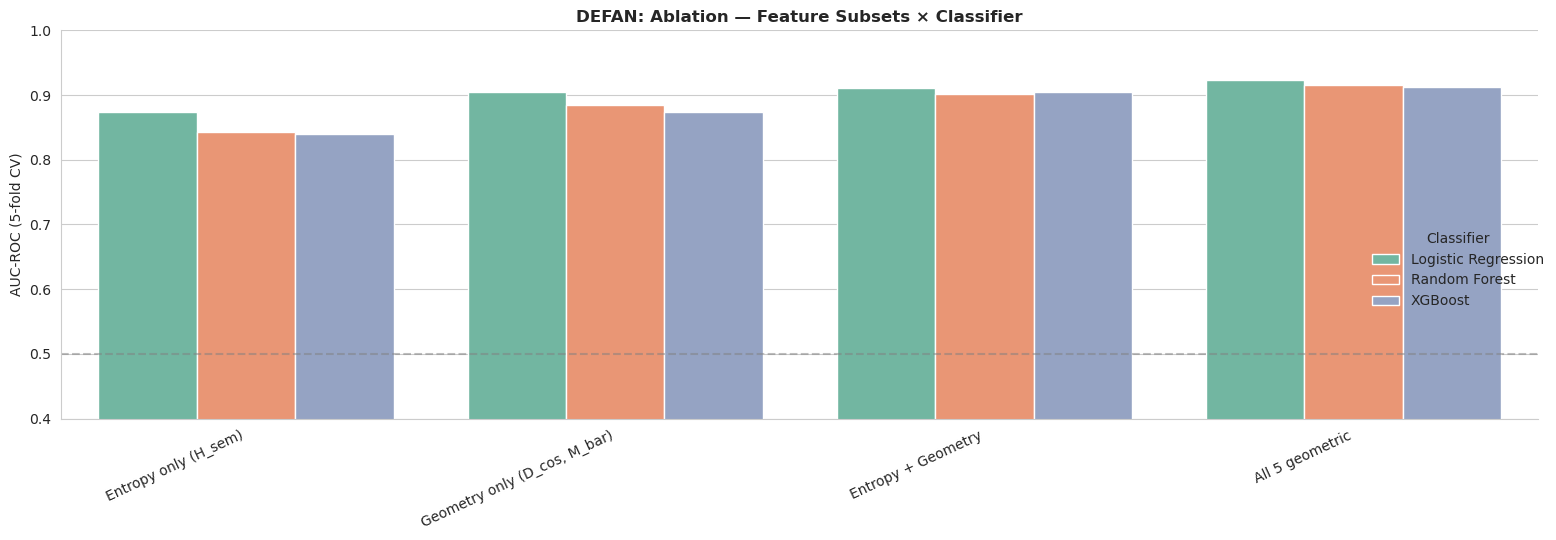

In [20]:
fig = plot_ablation_bar(df_clf_defan, dataset_name='DEFAN')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: Ablation ROC Curves


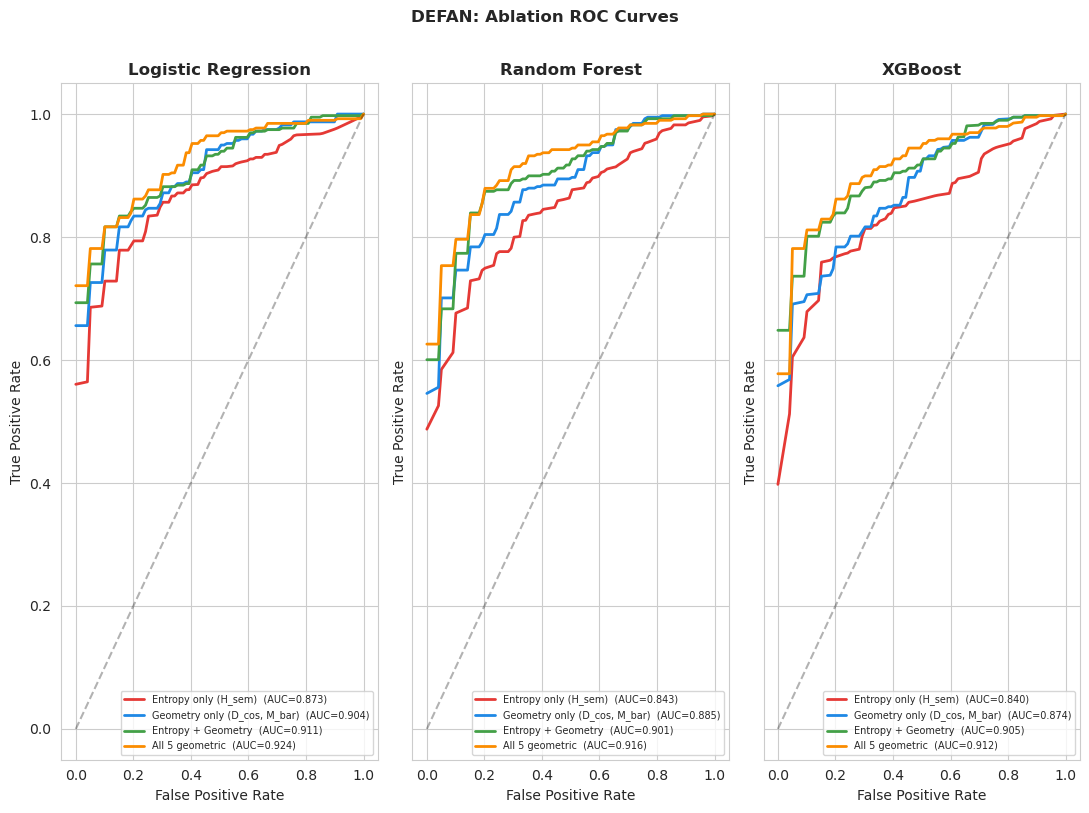

In [21]:
fig = plot_ablation_roc_curves(
    X_sc_defan, y_defan,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='DEFAN', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: Feature ROC Curves


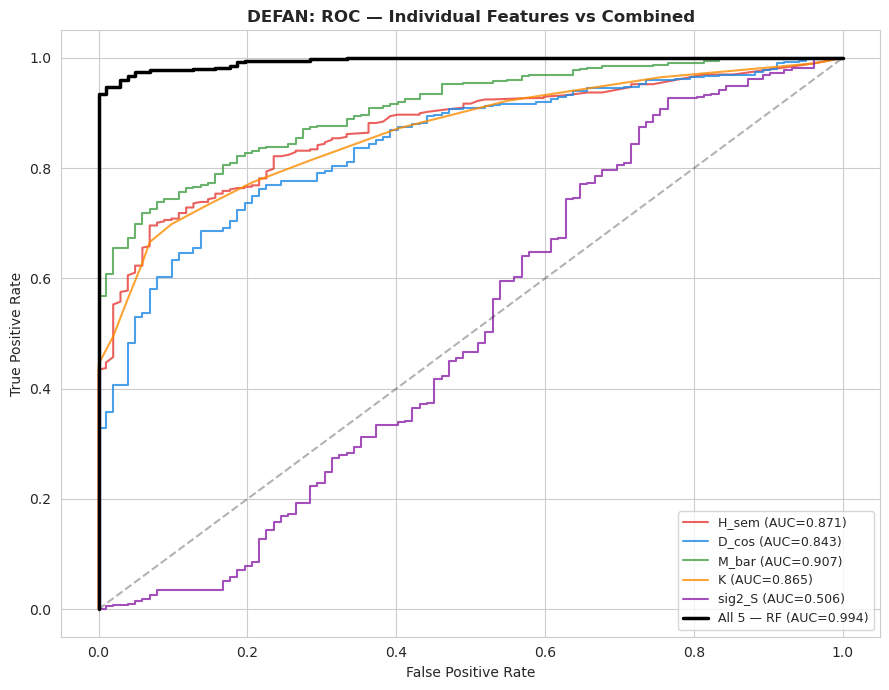

In [22]:
fig = plot_roc_curves(X_sc_defan, y_defan, dataset_name='DEFAN',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


The curve farthest from the diagonal is the single most discriminative feature.
If individual curves are all close to the diagonal, the combined RF (black) should
still show meaningful lift by combining feature signals.


### DEFAN: Per-Domain Classification


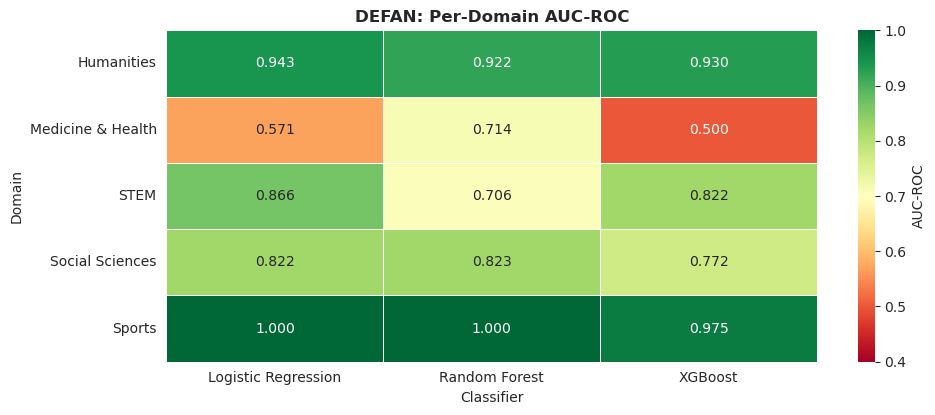

In [23]:
analysis_domains_defan, excluded_defan = split_analysis_domains(
    feat_dfs['defan'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain',
)
df_dom_defan = run_per_domain_clf(
    feat_dfs['defan'],
    analysis_domains=analysis_domains_defan,
    excluded_domains=excluded_defan,
    domain_col='domain', random_seed=RANDOM_SEED,
)
df_dom_defan.to_csv(os.path.join(OUTPUT_DIR, 'defan_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_defan, dataset_name='DEFAN')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: SHAP (benchmark-level only)


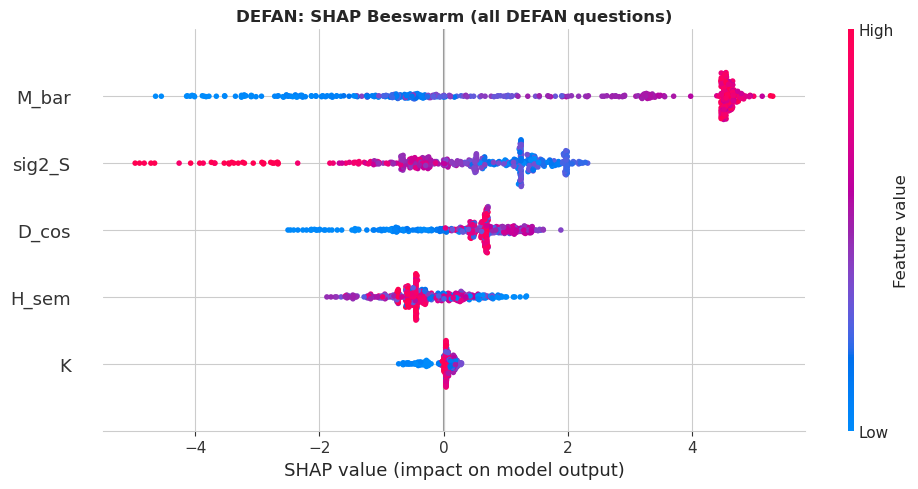

In [24]:
fig = plot_shap_beeswarm(
    X_sc_defan, y_defan,
    title='DEFAN: SHAP Beeswarm (all DEFAN questions)',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## HALUEVAL


### HALUEVAL: Ablation


In [25]:
df_clf_halueval, X_sc_halueval, y_halueval = run_ablation(
    feat_dfs['halueval'], random_seed=RANDOM_SEED,
)
df_clf_halueval.to_csv(os.path.join(OUTPUT_DIR, 'halueval_ablation.csv'), index=False)
display(df_clf_halueval.pivot_table(index='Variant', columns='Classifier',
                                       values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8062 ± 0.0831
  Entropy only (H_sem)                | Random Forest          | AUC = 0.7700 ± 0.1168
  Entropy only (H_sem)                | XGBoost                | AUC = 0.7617 ± 0.0940
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.7452 ± 0.1139
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.8926 ± 0.0376
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.8942 ± 0.0469
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.7497 ± 0.1297
  Entropy + Geometry                  | Random Forest          | AUC = 0.8792 ± 0.0526
  Entropy + Geometry                  | XGBoost                | AUC = 0.8878 ± 0.0618
  All 5 geometric                     | Logistic Regression    | AUC = 0.7765 ± 0.1015
  All 5 geometric                     | Random Forest          | AUC = 0.8726 ± 0.0511
  All 5 geometric                     | XGB

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 geometric,0.776,0.873,0.866
Entropy + Geometry,0.750,0.879,0.888
Entropy only (H_sem),0.806,0.770,0.762
"Geometry only (D_cos, M_bar)",0.745,0.893,0.894


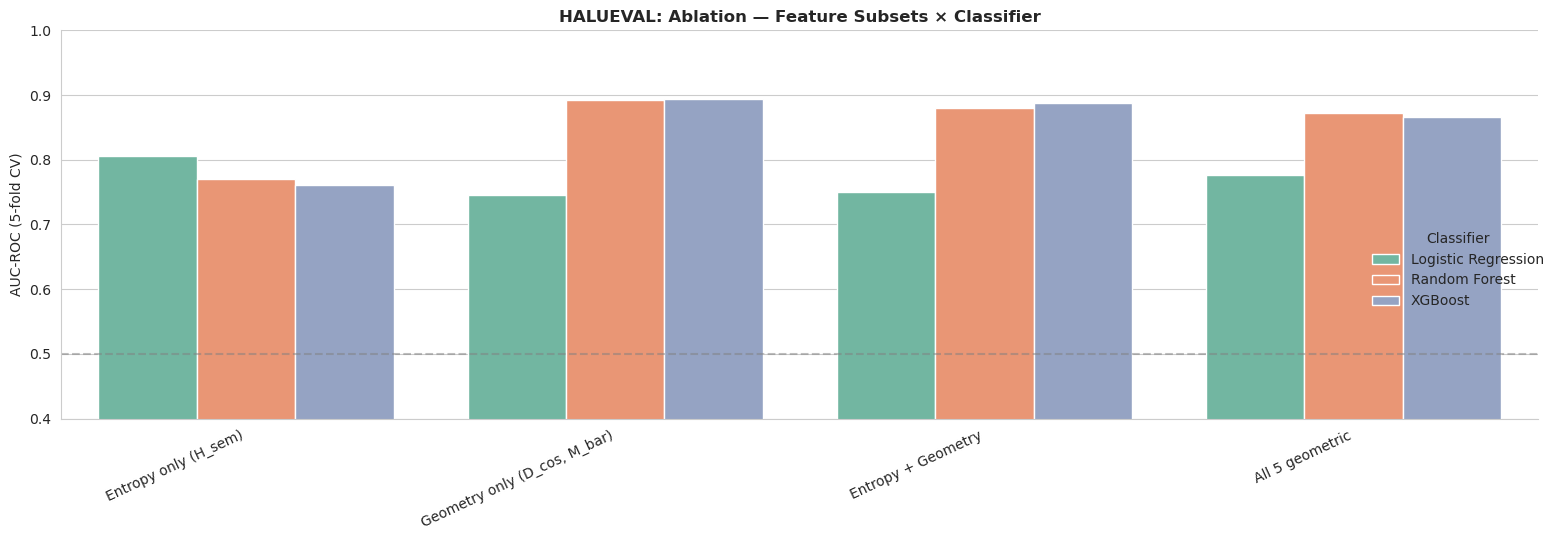

In [26]:
fig = plot_ablation_bar(df_clf_halueval, dataset_name='HALUEVAL')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: Ablation ROC Curves


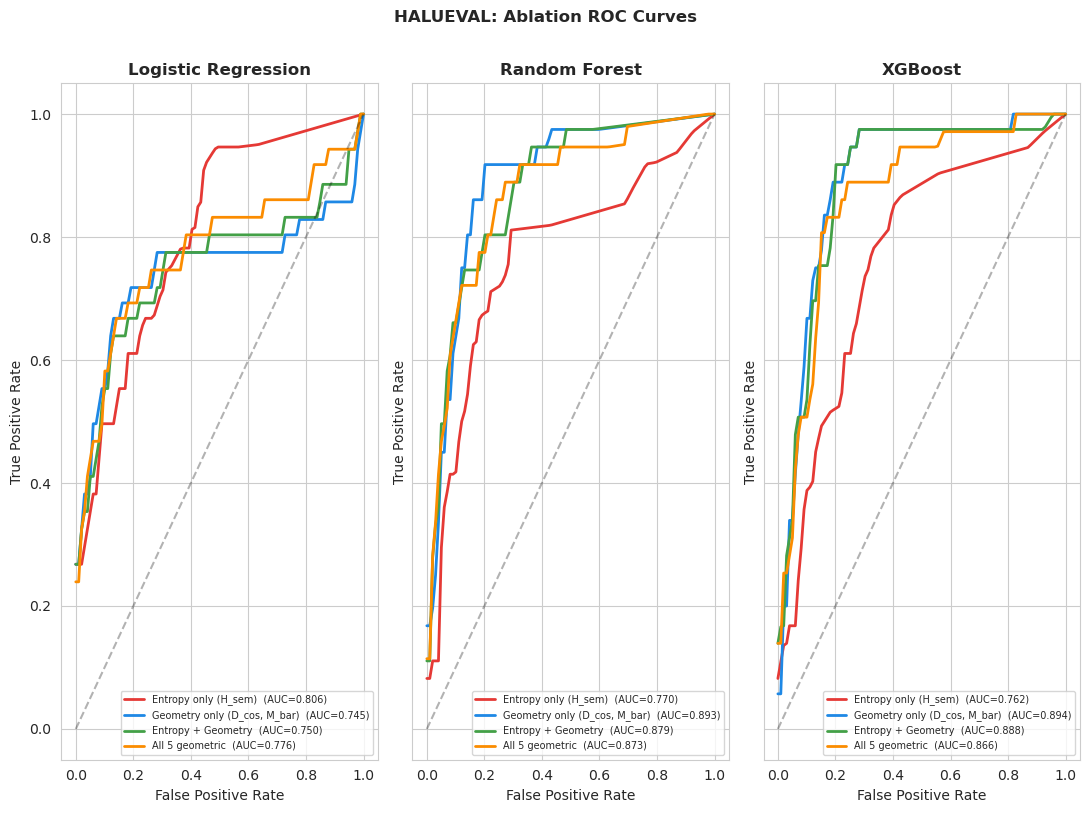

In [27]:
fig = plot_ablation_roc_curves(
    X_sc_halueval, y_halueval,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='HALUEVAL', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: Feature ROC Curves


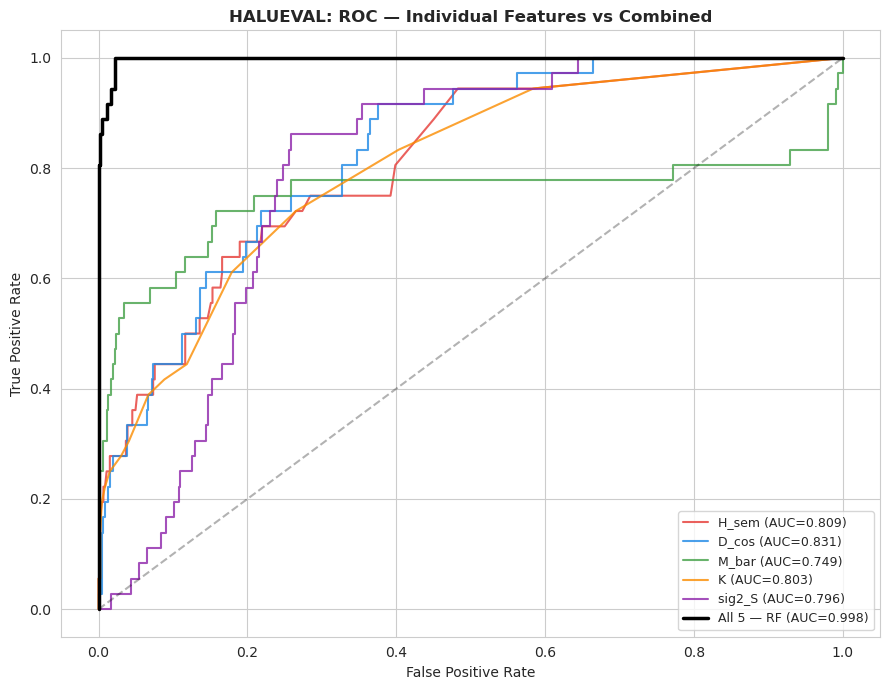

In [28]:
fig = plot_roc_curves(X_sc_halueval, y_halueval, dataset_name='HALUEVAL',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


The curve farthest from the diagonal is the single most discriminative feature.
If individual curves are all close to the diagonal, the combined RF (black) should
still show meaningful lift by combining feature signals.


### HALUEVAL: Per-Domain Classification


Excluded from per-domain classification: ['Medicine & Health']


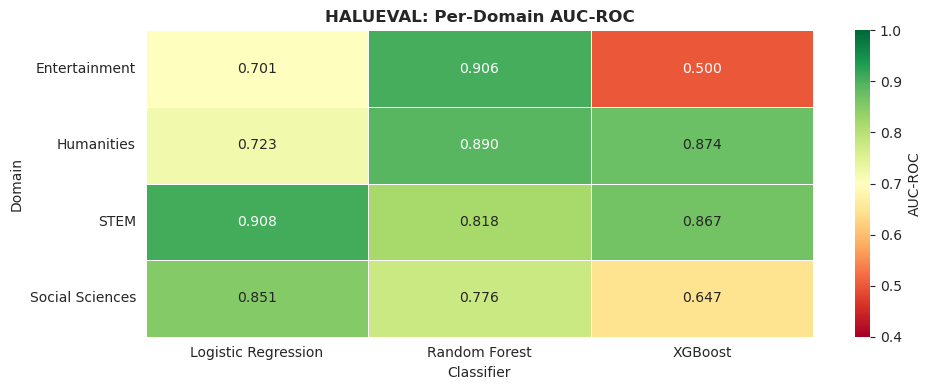

In [29]:
analysis_domains_halueval, excluded_halueval = split_analysis_domains(
    feat_dfs['halueval'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_halueval = run_per_domain_clf(
    feat_dfs['halueval'],
    analysis_domains=analysis_domains_halueval,
    excluded_domains=excluded_halueval,
    domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_halueval.to_csv(os.path.join(OUTPUT_DIR, 'halueval_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_halueval, dataset_name='HALUEVAL')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: SHAP (benchmark-level only)


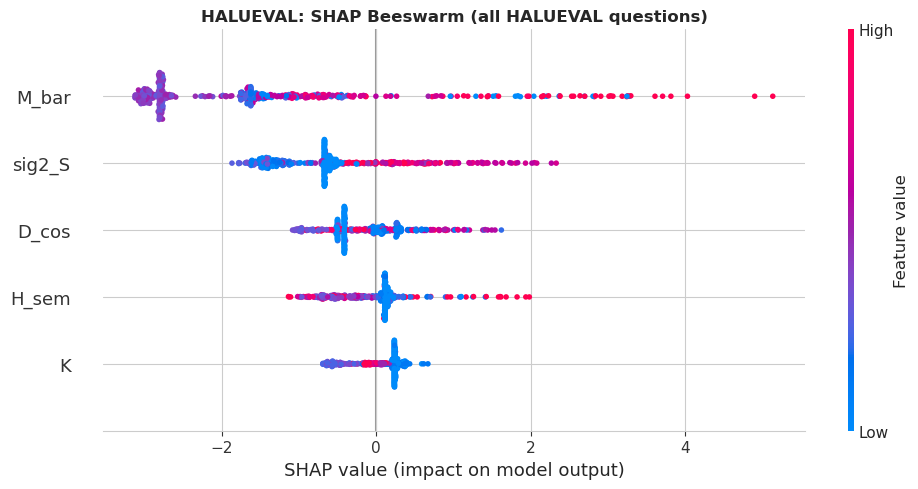

In [30]:
fig = plot_shap_beeswarm(
    X_sc_halueval, y_halueval,
    title='HALUEVAL: SHAP Beeswarm (all HALUEVAL questions)',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## MMLU


### MMLU: Ablation


In [31]:
df_clf_mmlu, X_sc_mmlu, y_mmlu = run_ablation(
    feat_dfs['mmlu'], random_seed=RANDOM_SEED,
)
df_clf_mmlu.to_csv(os.path.join(OUTPUT_DIR, 'mmlu_ablation.csv'), index=False)
display(df_clf_mmlu.pivot_table(index='Variant', columns='Classifier',
                                       values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.6992 ± 0.0496
  Entropy only (H_sem)                | Random Forest          | AUC = 0.6130 ± 0.0556
  Entropy only (H_sem)                | XGBoost                | AUC = 0.5746 ± 0.0902
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9426 ± 0.0236
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9339 ± 0.0341
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.9228 ± 0.0374
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9431 ± 0.0225
  Entropy + Geometry                  | Random Forest          | AUC = 0.9229 ± 0.0353
  Entropy + Geometry                  | XGBoost                | AUC = 0.9109 ± 0.0385
  All 5 geometric                     | Logistic Regression    | AUC = 0.9460 ± 0.0183
  All 5 geometric                     | Random Forest          | AUC = 0.9249 ± 0.0321
  All 5 geometric                     | XGB

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 geometric,0.946,0.925,0.918
Entropy + Geometry,0.943,0.923,0.911
Entropy only (H_sem),0.699,0.613,0.575
"Geometry only (D_cos, M_bar)",0.943,0.934,0.923


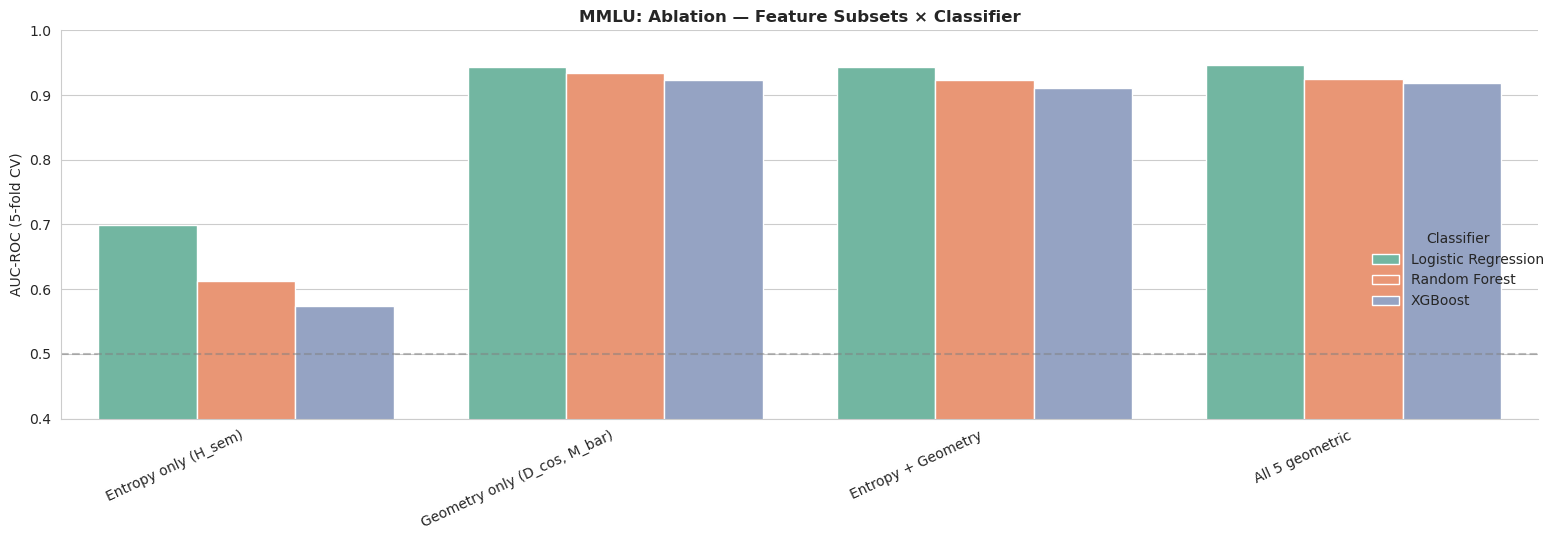

In [32]:
fig = plot_ablation_bar(df_clf_mmlu, dataset_name='MMLU')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: Ablation ROC Curves


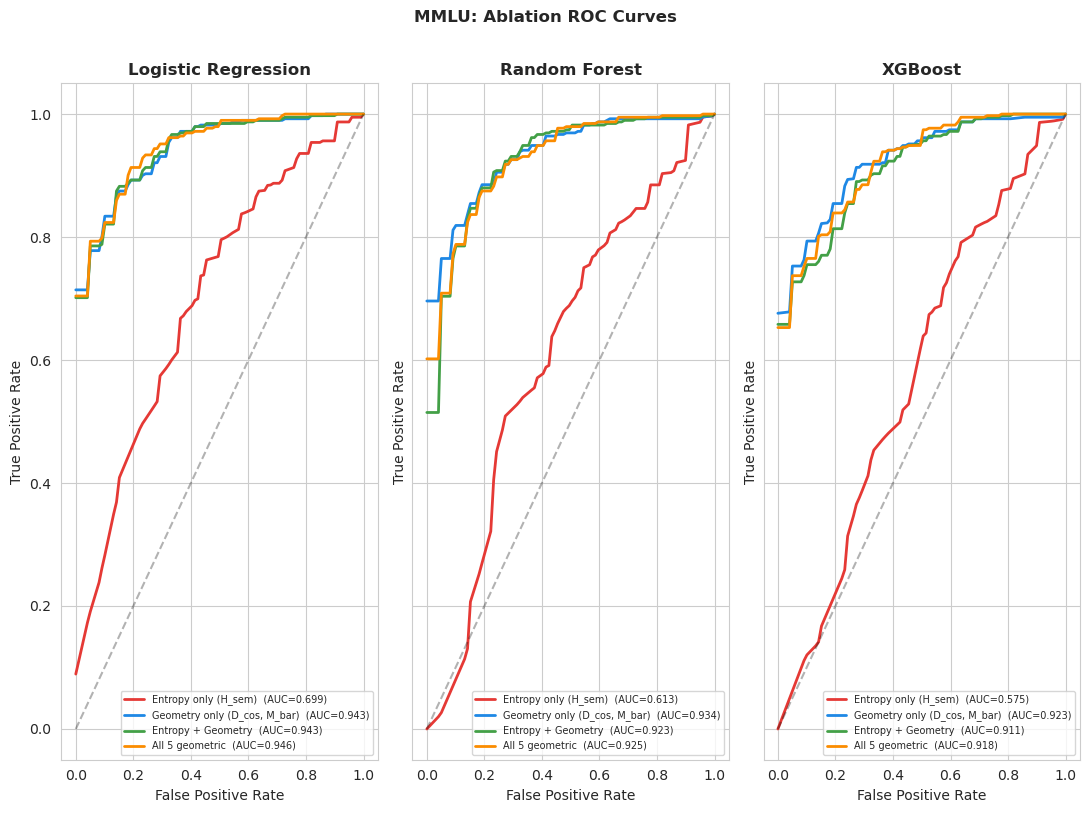

In [33]:
fig = plot_ablation_roc_curves(
    X_sc_mmlu, y_mmlu,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='MMLU', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: Feature ROC Curves


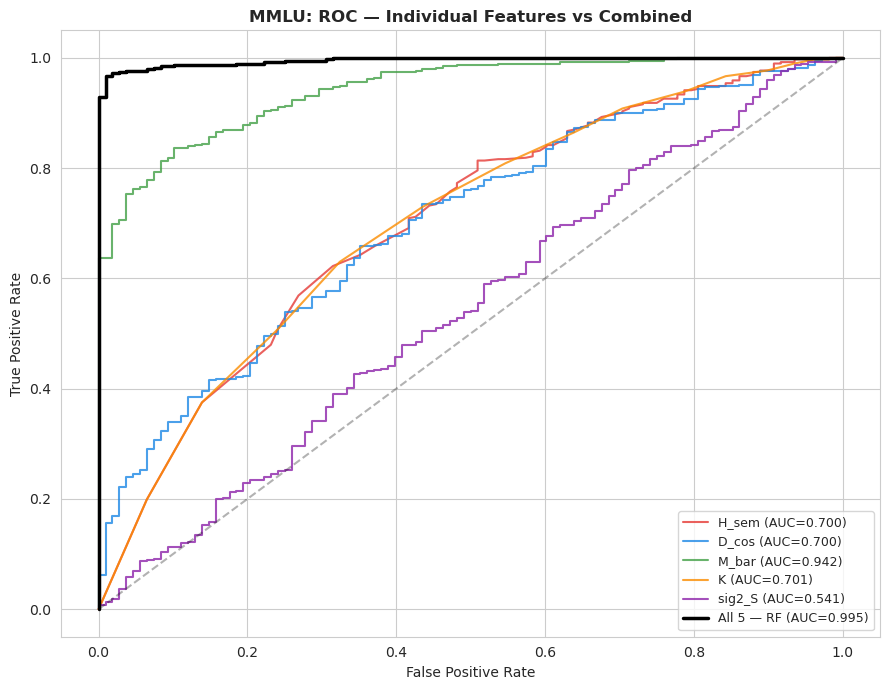

In [34]:
fig = plot_roc_curves(X_sc_mmlu, y_mmlu, dataset_name='MMLU',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


The curve farthest from the diagonal is the single most discriminative feature.
If individual curves are all close to the diagonal, the combined RF (black) should
still show meaningful lift by combining feature signals.


### MMLU: Per-Domain Classification


Excluded from per-domain classification: ['Entertainment', 'Food & Nutrition', 'Sports']


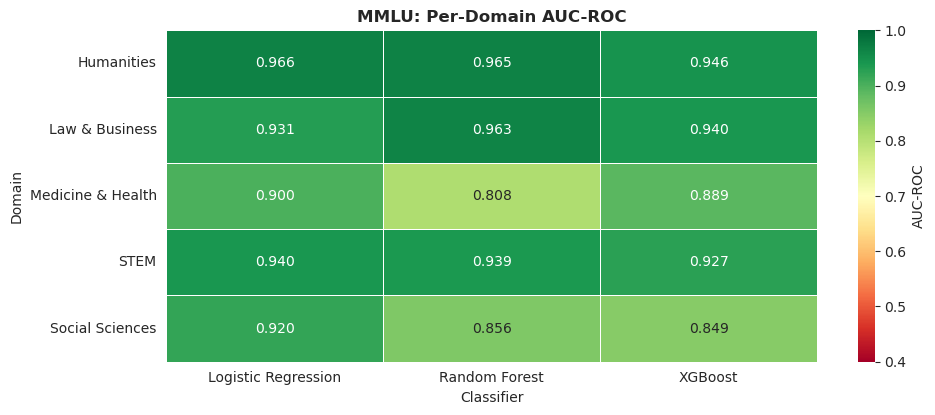

In [35]:
analysis_domains_mmlu, excluded_mmlu = split_analysis_domains(
    feat_dfs['mmlu'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_mmlu = run_per_domain_clf(
    feat_dfs['mmlu'],
    analysis_domains=analysis_domains_mmlu,
    excluded_domains=excluded_mmlu,
    domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_mmlu.to_csv(os.path.join(OUTPUT_DIR, 'mmlu_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_mmlu, dataset_name='MMLU')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: SHAP (benchmark-level only)


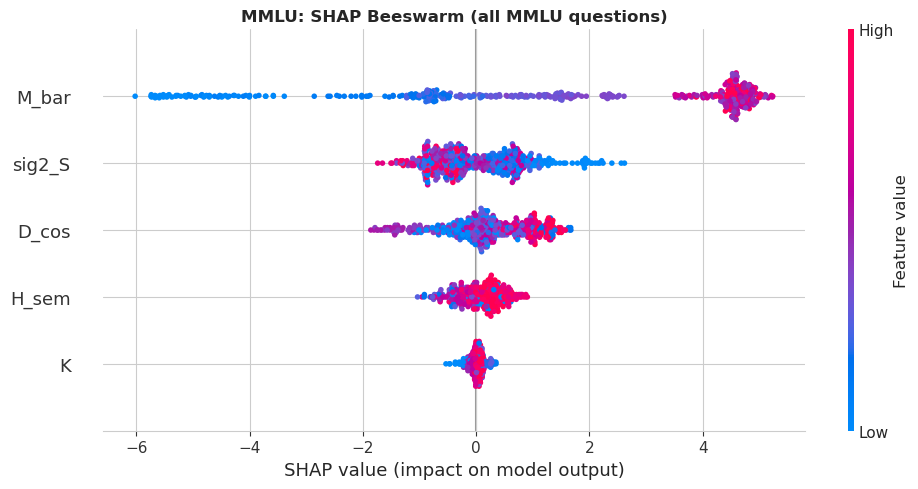

In [36]:
fig = plot_shap_beeswarm(
    X_sc_mmlu, y_mmlu,
    title='MMLU: SHAP Beeswarm (all MMLU questions)',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## TRIVIAQA


### TRIVIAQA: Ablation


In [37]:
df_clf_triviaqa, X_sc_triviaqa, y_triviaqa = run_ablation(
    feat_dfs['triviaqa'], random_seed=RANDOM_SEED,
)
df_clf_triviaqa.to_csv(os.path.join(OUTPUT_DIR, 'triviaqa_ablation.csv'), index=False)
display(df_clf_triviaqa.pivot_table(index='Variant', columns='Classifier',
                                       values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.9100 ± 0.0288
  Entropy only (H_sem)                | Random Forest          | AUC = 0.8979 ± 0.0336
  Entropy only (H_sem)                | XGBoost                | AUC = 0.8979 ± 0.0258
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9717 ± 0.0105
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9639 ± 0.0065
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.9627 ± 0.0122
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9722 ± 0.0102
  Entropy + Geometry                  | Random Forest          | AUC = 0.9658 ± 0.0069
  Entropy + Geometry                  | XGBoost                | AUC = 0.9591 ± 0.0137
  All 5 geometric                     | Logistic Regression    | AUC = 0.9736 ± 0.0097
  All 5 geometric                     | Random Forest          | AUC = 0.9694 ± 0.0098
  All 5 geometric                     | XGB

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 geometric,0.974,0.969,0.968
Entropy + Geometry,0.972,0.966,0.959
Entropy only (H_sem),0.910,0.898,0.898
"Geometry only (D_cos, M_bar)",0.972,0.964,0.963


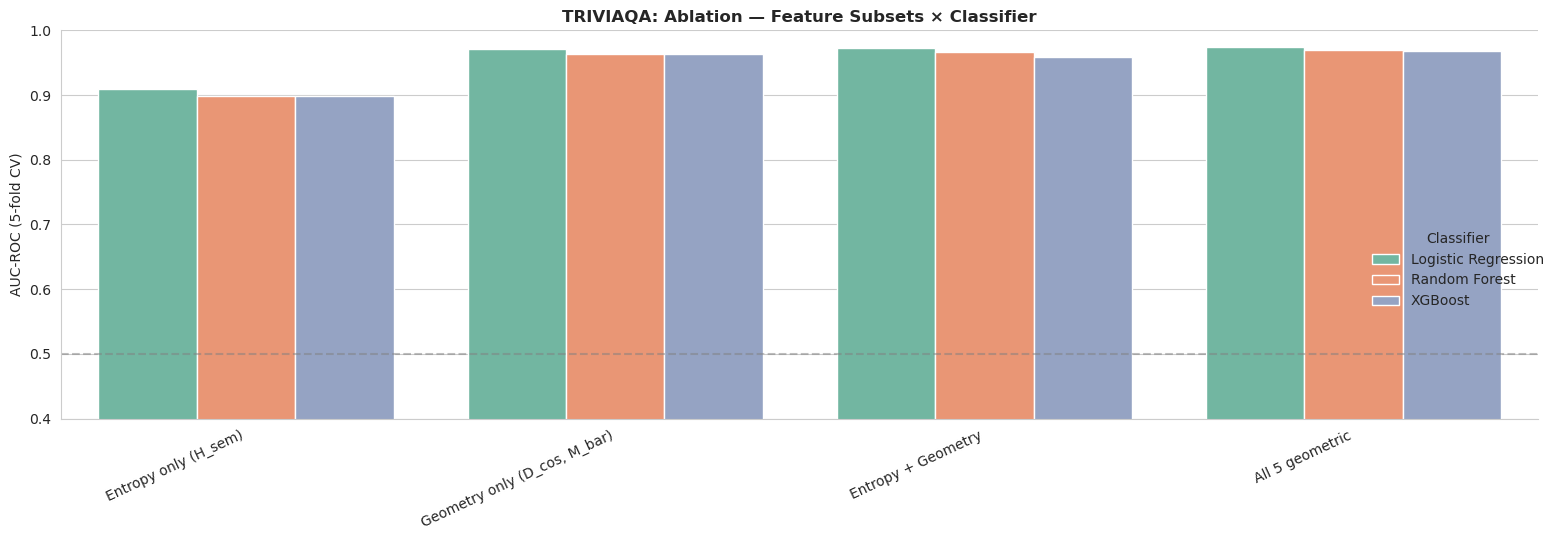

In [38]:
fig = plot_ablation_bar(df_clf_triviaqa, dataset_name='TRIVIAQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: Ablation ROC Curves


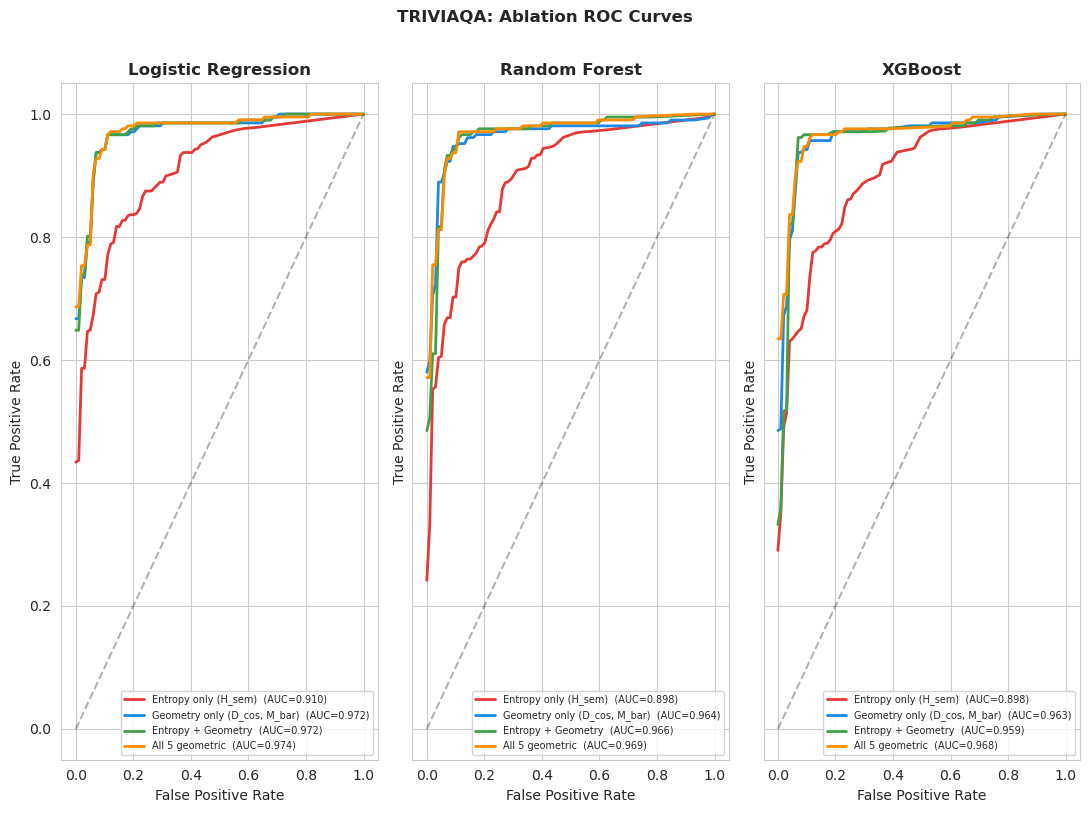

In [39]:
fig = plot_ablation_roc_curves(
    X_sc_triviaqa, y_triviaqa,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='TRIVIAQA', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: Feature ROC Curves


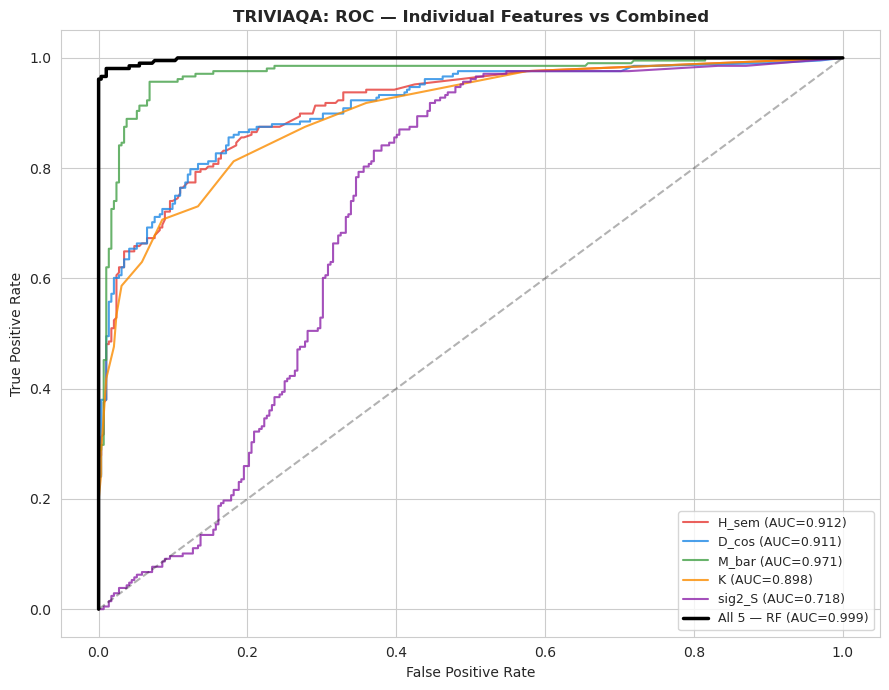

In [40]:
fig = plot_roc_curves(X_sc_triviaqa, y_triviaqa, dataset_name='TRIVIAQA',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


The curve farthest from the diagonal is the single most discriminative feature.
If individual curves are all close to the diagonal, the combined RF (black) should
still show meaningful lift by combining feature signals.


### TRIVIAQA: Per-Domain Classification


Excluded from per-domain classification: ['Geography', 'History', 'Language', 'Law & Business', 'Literature', 'Other', 'Religion & Philosophy', 'Science']


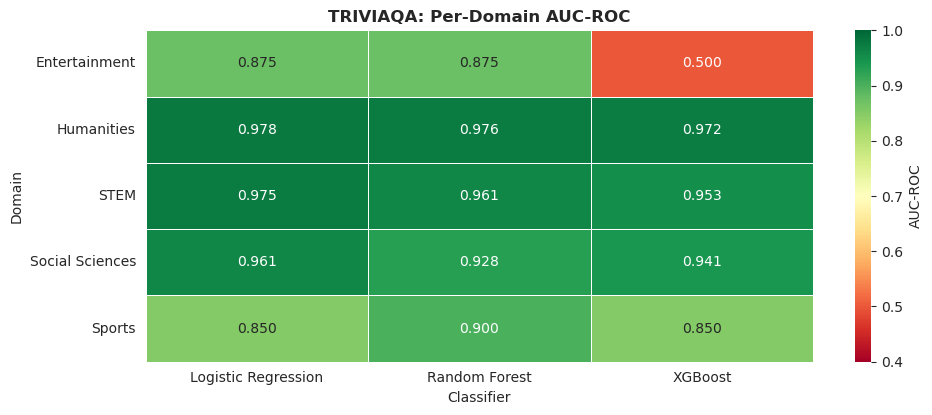

In [41]:
analysis_domains_triviaqa, excluded_triviaqa = split_analysis_domains(
    feat_dfs['triviaqa'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_triviaqa = run_per_domain_clf(
    feat_dfs['triviaqa'],
    analysis_domains=analysis_domains_triviaqa,
    excluded_domains=excluded_triviaqa,
    domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_triviaqa.to_csv(os.path.join(OUTPUT_DIR, 'triviaqa_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_triviaqa, dataset_name='TRIVIAQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: SHAP (benchmark-level only)


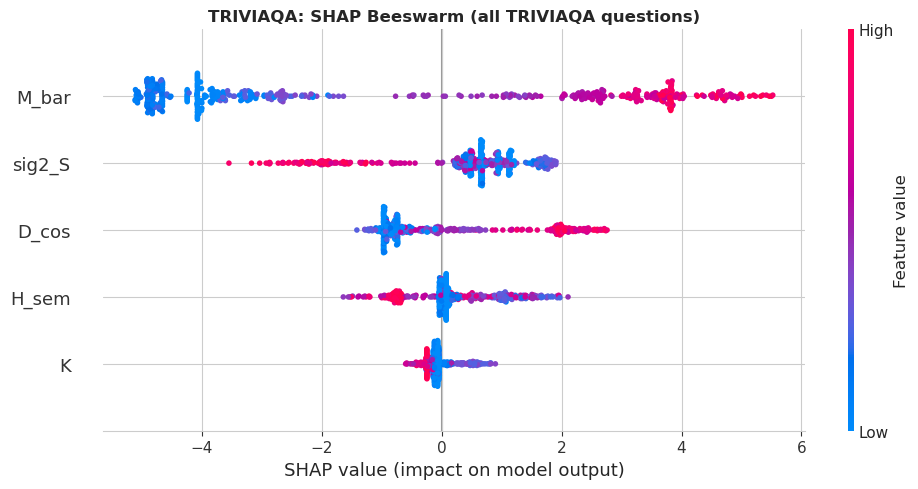

In [42]:
fig = plot_shap_beeswarm(
    X_sc_triviaqa, y_triviaqa,
    title='TRIVIAQA: SHAP Beeswarm (all TRIVIAQA questions)',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## TRUTHFULQA


### TRUTHFULQA: Ablation


In [43]:
df_clf_truthfulqa, X_sc_truthfulqa, y_truthfulqa = run_ablation(
    feat_dfs['truthfulqa'], random_seed=RANDOM_SEED,
)
df_clf_truthfulqa.to_csv(os.path.join(OUTPUT_DIR, 'truthfulqa_ablation.csv'), index=False)
display(df_clf_truthfulqa.pivot_table(index='Variant', columns='Classifier',
                                       values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.7277 ± 0.0564
  Entropy only (H_sem)                | Random Forest          | AUC = 0.6404 ± 0.0780
  Entropy only (H_sem)                | XGBoost                | AUC = 0.6416 ± 0.0571
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9235 ± 0.0318
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9277 ± 0.0334
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.9167 ± 0.0407
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9231 ± 0.0322
  Entropy + Geometry                  | Random Forest          | AUC = 0.9315 ± 0.0369
  Entropy + Geometry                  | XGBoost                | AUC = 0.9231 ± 0.0394
  All 5 geometric                     | Logistic Regression    | AUC = 0.9219 ± 0.0339
  All 5 geometric                     | Random Forest          | AUC = 0.9337 ± 0.0423
  All 5 geometric                     | XGB

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 geometric,0.922,0.934,0.937
Entropy + Geometry,0.923,0.931,0.923
Entropy only (H_sem),0.728,0.640,0.642
"Geometry only (D_cos, M_bar)",0.923,0.928,0.917


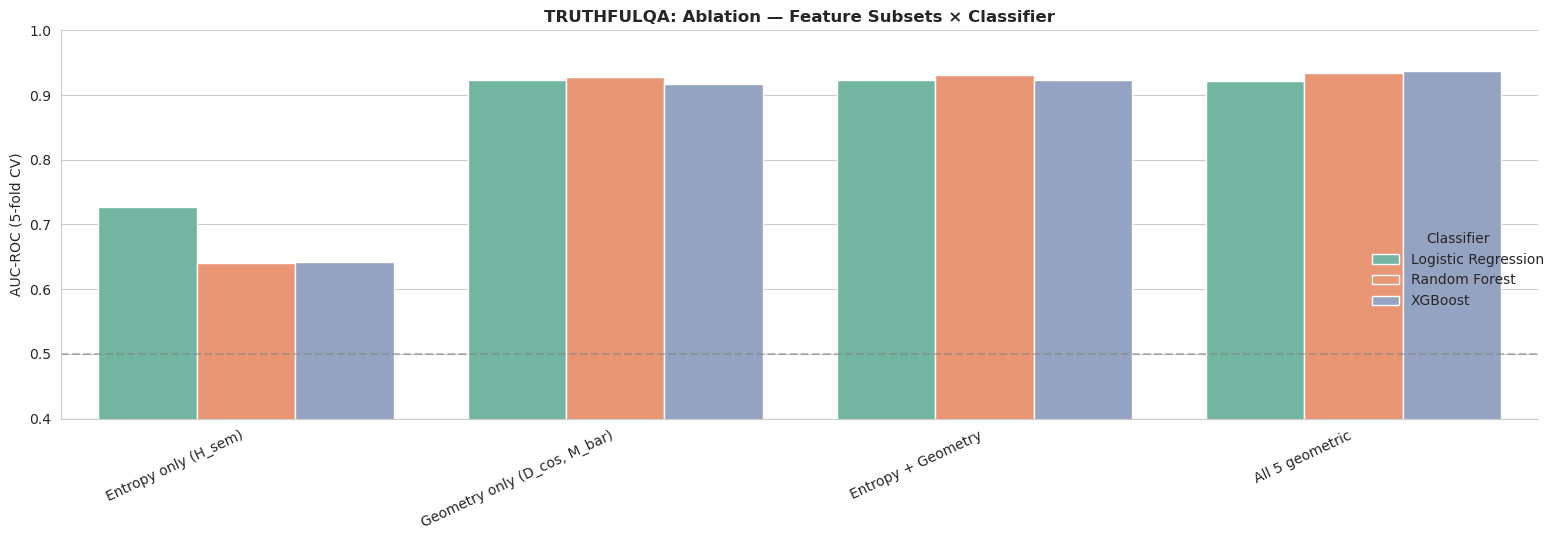

In [44]:
fig = plot_ablation_bar(df_clf_truthfulqa, dataset_name='TRUTHFULQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: Ablation ROC Curves


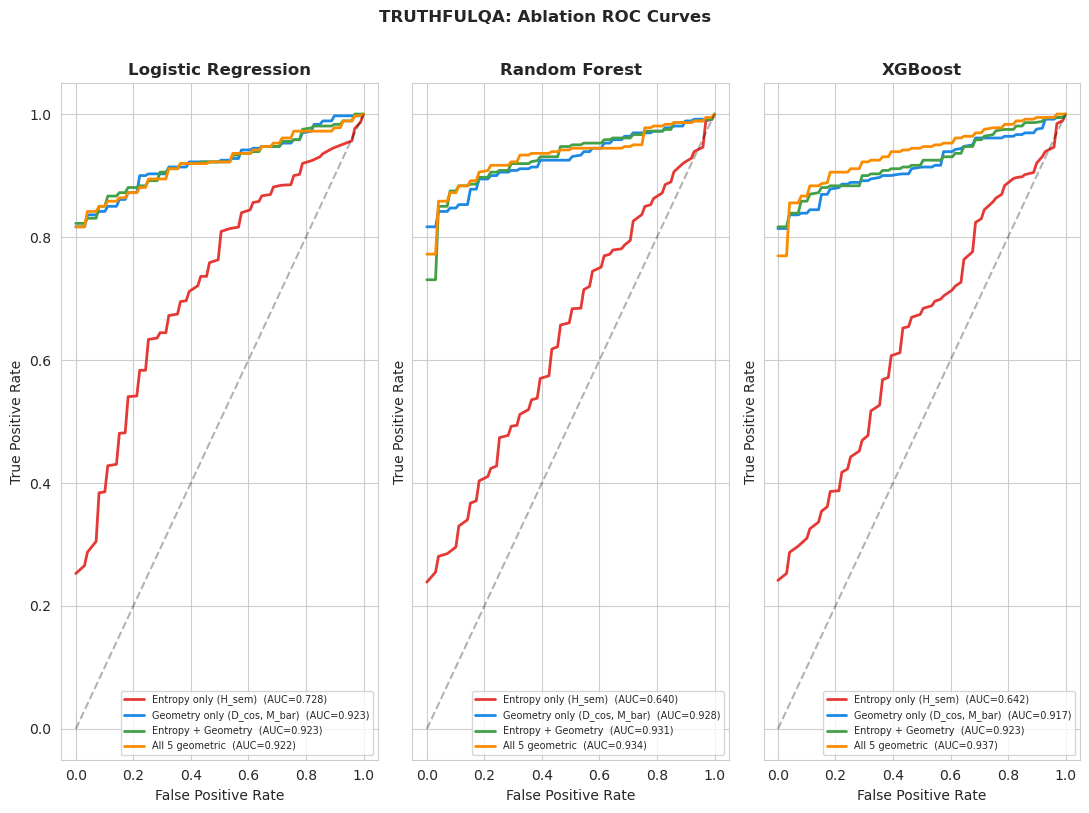

In [45]:
fig = plot_ablation_roc_curves(
    X_sc_truthfulqa, y_truthfulqa,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='TRUTHFULQA', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: Feature ROC Curves


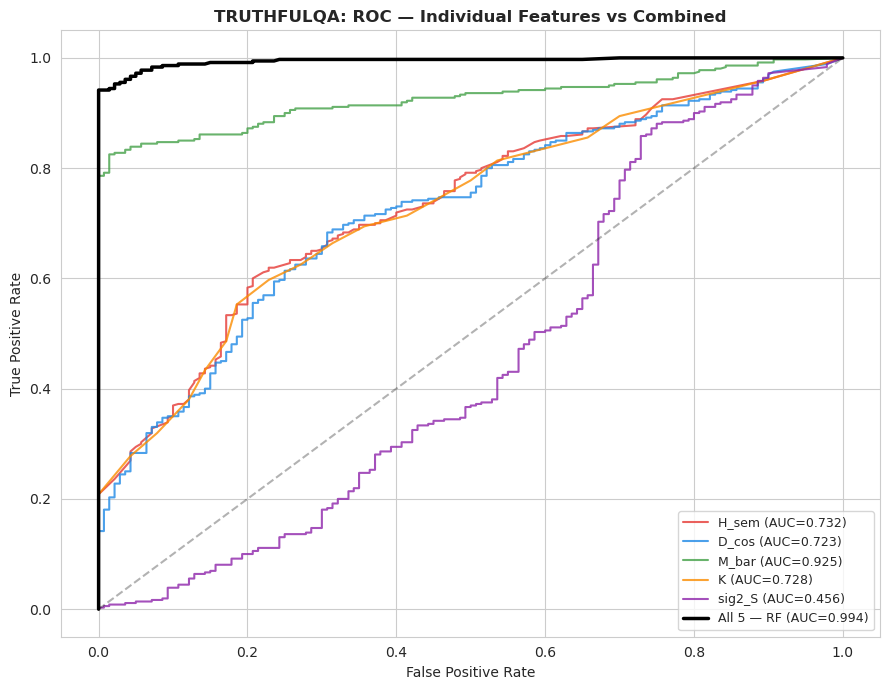

In [46]:
fig = plot_roc_curves(X_sc_truthfulqa, y_truthfulqa, dataset_name='TRUTHFULQA',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


The curve farthest from the diagonal is the single most discriminative feature.
If individual curves are all close to the diagonal, the combined RF (black) should
still show meaningful lift by combining feature signals.


### TRUTHFULQA: Per-Domain Classification


Excluded from per-domain classification: ['Entertainment', 'Food & Nutrition', 'Geography', 'History', 'Language', 'Literature', 'Mathematics', 'Other', 'Science', 'Sports']


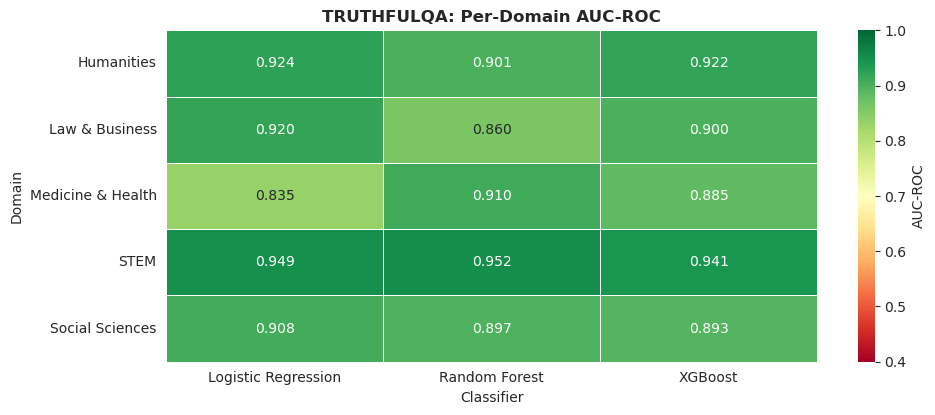

In [47]:
analysis_domains_truthfulqa, excluded_truthfulqa = split_analysis_domains(
    feat_dfs['truthfulqa'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_truthfulqa = run_per_domain_clf(
    feat_dfs['truthfulqa'],
    analysis_domains=analysis_domains_truthfulqa,
    excluded_domains=excluded_truthfulqa,
    domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_truthfulqa.to_csv(os.path.join(OUTPUT_DIR, 'truthfulqa_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_truthfulqa, dataset_name='TRUTHFULQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: SHAP (benchmark-level only)


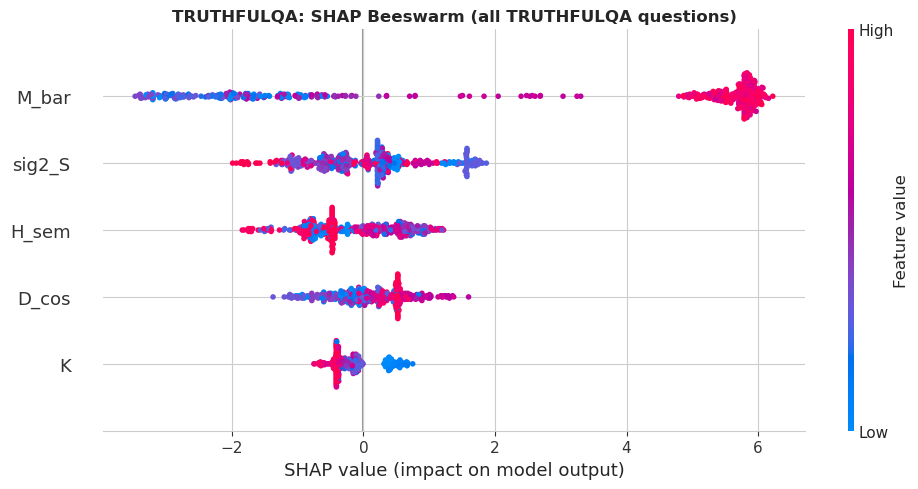

In [48]:
fig = plot_shap_beeswarm(
    X_sc_truthfulqa, y_truthfulqa,
    title='TRUTHFULQA: SHAP Beeswarm (all TRUTHFULQA questions)',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Combined Dataset — All 2 500 Questions


### Combined: Ablation


In [49]:
df_clf_all, X_sc_all, y_all = run_ablation(feat_all, random_seed=RANDOM_SEED)
df_clf_all.to_csv(os.path.join(OUTPUT_DIR, 'combined_ablation.csv'), index=False)
display(df_clf_all.pivot_table(index='Variant', columns='Classifier',
                                values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8622 ± 0.0105
  Entropy only (H_sem)                | Random Forest          | AUC = 0.8534 ± 0.0126
  Entropy only (H_sem)                | XGBoost                | AUC = 0.8471 ± 0.0122
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.8972 ± 0.0136
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9287 ± 0.0133
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.9237 ± 0.0152
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9217 ± 0.0107
  Entropy + Geometry                  | Random Forest          | AUC = 0.9466 ± 0.0107
  Entropy + Geometry                  | XGBoost                | AUC = 0.9457 ± 0.0105
  All 5 geometric                     | Logistic Regression    | AUC = 0.9200 ± 0.0105
  All 5 geometric                     | Random Forest          | AUC = 0.9493 ± 0.0092
  All 5 geometric                     | XGB

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 geometric,0.920,0.949,0.946
Entropy + Geometry,0.922,0.947,0.946
Entropy only (H_sem),0.862,0.853,0.847
"Geometry only (D_cos, M_bar)",0.897,0.929,0.924


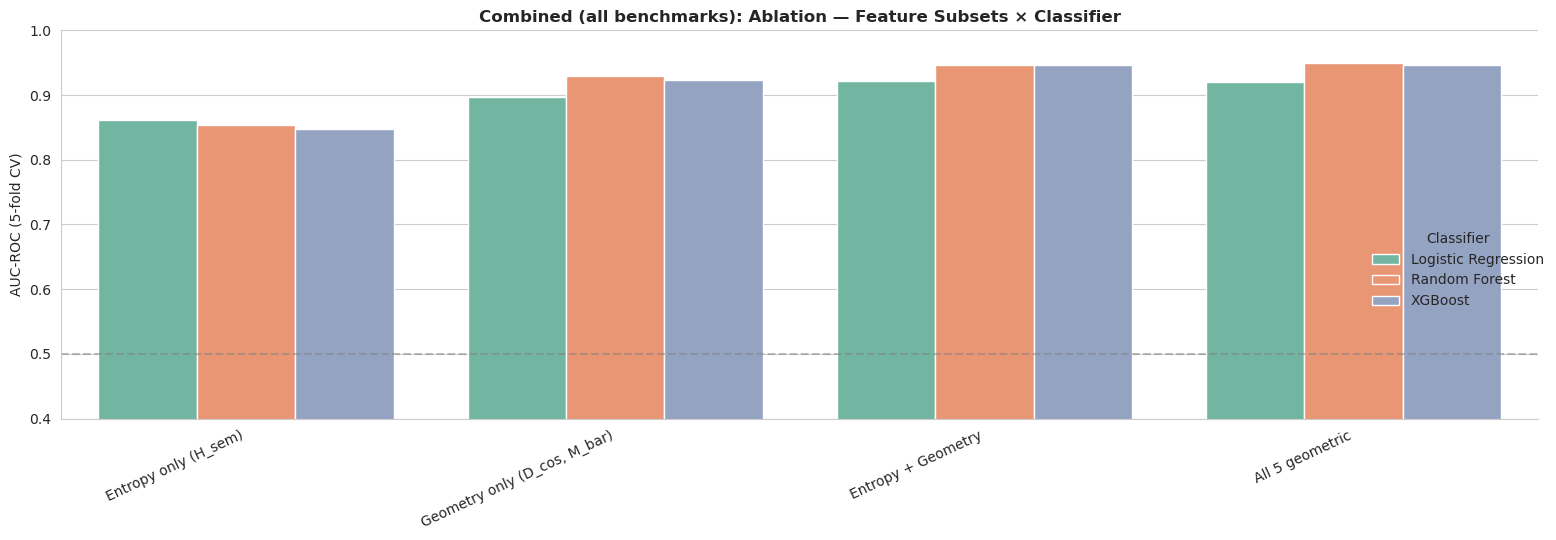

In [50]:
fig = plot_ablation_bar(df_clf_all, dataset_name='Combined (all benchmarks)')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Ablation ROC Curves


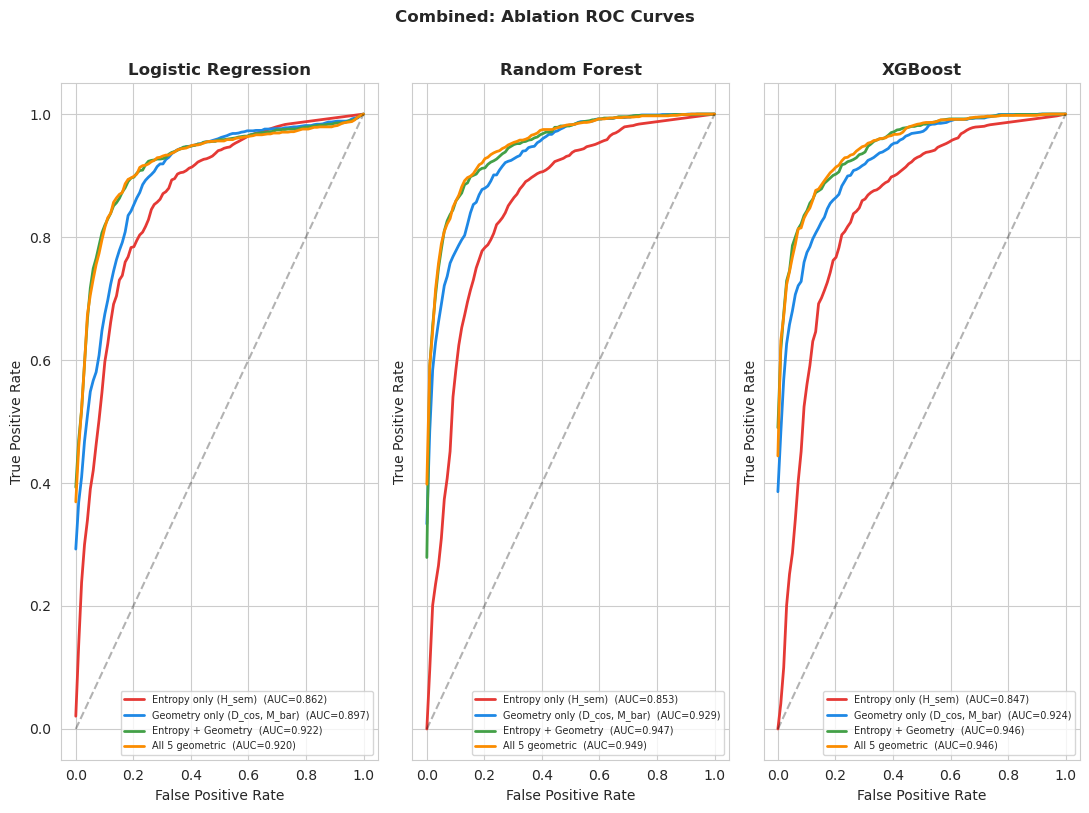

In [51]:
fig = plot_ablation_roc_curves(
    X_sc_all, y_all,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='Combined', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Feature ROC Curves


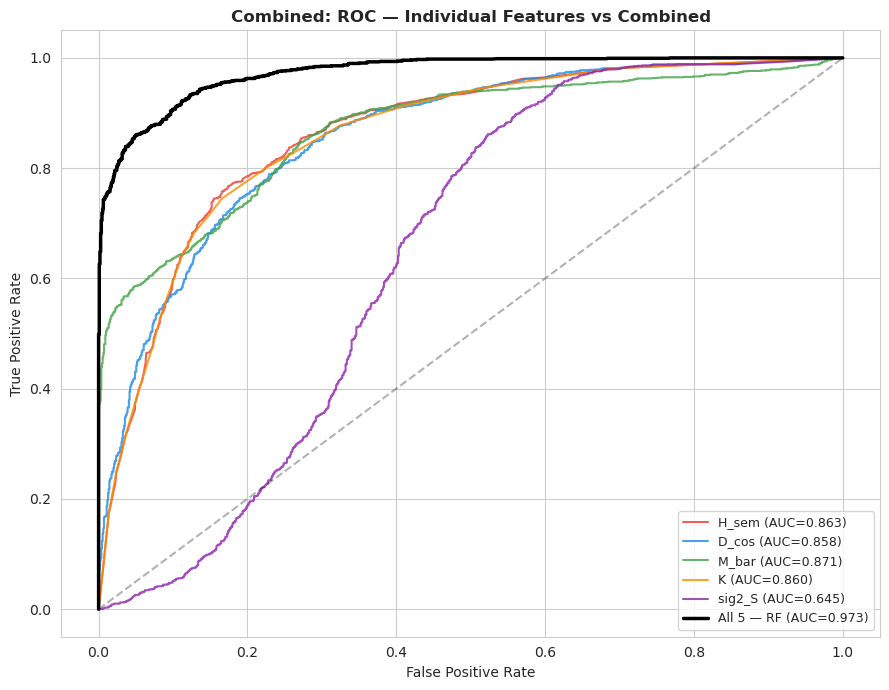

In [52]:
fig = plot_roc_curves(X_sc_all, y_all, dataset_name='Combined', random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Per-Domain Classification (by benchmark)


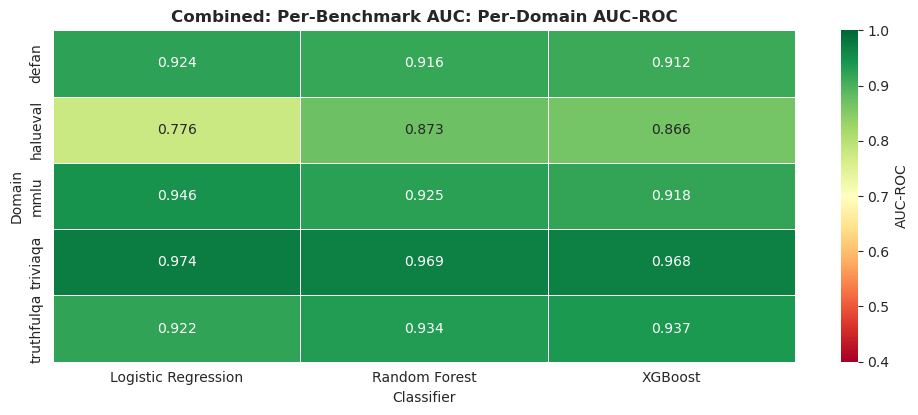

In [53]:
# Classify by benchmark dataset as a pseudo-domain for the combined set
from spectral_detection.training import run_per_domain_clf
all_datasets = sorted(feat_all['dataset'].unique())
feat_all_tmp = feat_all.copy()
feat_all_tmp['domain'] = feat_all_tmp['dataset']
df_dom_all = run_per_domain_clf(
    feat_all_tmp,
    analysis_domains=all_datasets,
    domain_col='domain',
    random_seed=RANDOM_SEED,
)
df_dom_all.to_csv(os.path.join(OUTPUT_DIR, 'combined_per_dataset_clf.csv'), index=False)
from spectral_detection.visualization import plot_per_domain_clf_heatmap
fig = plot_per_domain_clf_heatmap(df_dom_all, dataset_name='Combined: Per-Benchmark AUC')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_per_dataset_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: SHAP (combined dataset)


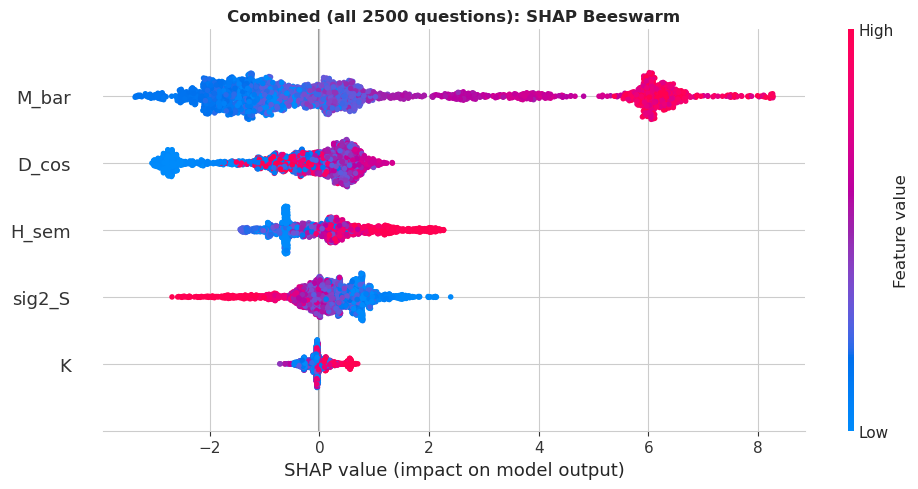

In [54]:
fig = plot_shap_beeswarm(
    X_sc_all, y_all,
    title='Combined (all 2500 questions): SHAP Beeswarm',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Cross-Benchmark Ablation Summary


In [55]:
# Show best AUC per dataset for a quick comparison
summary = []
for ds in ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa', 'combined']:
    df_c = pd.read_csv(os.path.join(OUTPUT_DIR, f'{ds}_ablation.csv'))
    best = df_c.loc[df_c['AUC_mean'].idxmax()]
    summary.append({'Dataset': ds, 'Best_Variant': best['Variant'],
                     'Best_Clf': best['Classifier'], 'AUC': round(best['AUC_mean'], 4)})
display(pd.DataFrame(summary))


,Dataset,Best_Variant,Best_Clf,AUC
0,defan,All 5 geometric,Logistic Regression,0.9239
1,halueval,"Geometry only (D_cos, M_bar)",XGBoost,0.8942
2,mmlu,All 5 geometric,Logistic Regression,0.9460
3,triviaqa,All 5 geometric,Logistic Regression,0.9736
4,truthfulqa,All 5 geometric,XGBoost,0.9371
5,combined,All 5 geometric,Random Forest,0.9493
